In [1]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

In [2]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana1/snert/max/data/amigo_files/"
    data_path = "/media/morgana1/snert/max/data/JWST/"
    uncal_path = "/media/morgana1/snert/max/data/JWST/"
else:
    cache = "/Volumes/morgana1/snert/max/data/amigo_files/"
    data_path = "/Users/mcha5804/JWST/"
    uncal_path = "/Users/mcha5804/JWST/"

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    "F430M",
    "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

In [3]:
def get_rgb(
    TARGPROP,
    PATT_NUM=1,
    NUMDTHPT=1,
):
    files = sorted(
        file_fn(data_path + "AB-DOR/calslope/"),
        key=lambda hdu: hdu[0].header.get("EXPMID", float("inf")),
    )

    channels = {}
    for file in files:
        if (
            file[0].header["PATT_NUM"] != PATT_NUM
            or file[0].header["NUMDTHPT"] != NUMDTHPT
        ):
            continue
        if file[0].header["TARGPROP"] == TARGPROP:
            for filt in FILTERS:
                if file[0].header["FILTER"] == filt:
                    channels[filt] = file

    return channels


def normalise_rgb(rgb_dict, p=1.0):

    r = np.array(rgb_dict["F480M"]["SLOPE"].data[0])
    g = np.array(rgb_dict["F430M"]["SLOPE"].data[0])
    b = np.array(rgb_dict["F380M"]["SLOPE"].data[0])

    r_badpix = np.array(rgb_dict["F480M"]["BADPIX"].data)
    g_badpix = np.array(rgb_dict["F430M"]["BADPIX"].data)
    b_badpix = np.array(rgb_dict["F380M"]["BADPIX"].data)

    badpix = r_badpix | g_badpix | b_badpix

    r_max = np.nanmax(r)
    g_max = np.nanmax(g)
    b_max = np.nanmax(b)
    maxx = np.nanmax(np.array([r_max, g_max, b_max]))

    r = np.clip(np.where(badpix, 0.0, r), 0.0) / maxx
    g = np.clip(np.where(badpix, 0.0, g), 0.0) / maxx
    b = np.clip(np.where(badpix, 0.0, b), 0.0) / maxx

    return np.stack([r**p, g**p, b**p], axis=-1)  # Shape: (H, W, 3)

# Loading in data

## AB-DOR

In [4]:
files = file_fn(
    data_path + "AB-DOR/calslope/",
    filters=FILTERS,
)

for file in files:
    print(
        file[0].header["TARGPROP"],
        file[0].header["PATT_NUM"],
        file[0].header["NUMDTHPT"],
    )

HD-36805 24 25
HD-37093 1 1
AB-DOR 1 1
HD-36805 6 25
HD-36805 16 25
HD-36805 13 25
HD-36805 3 25
AB-DOR 1 5
AB-DOR 4 5
HD-36805 1 1
AB-DOR 1 1
HD-36805 14 25
HD-36805 4 25
HD-36805 1 25
HD-36805 11 25
HD-36805 9 25
AB-DOR 1 1
HD-36805 8 25
HD-36805 19 25
AB-DOR 1 1
HD-36805 25 25
AB-DOR 1 1
HD-37093 4 5
HD-36805 15 25
AB-DOR 1 1
HD-36805 12 25
HD-36805 22 25
HD-36805 7 25
HD-37093 3 5
HD-37093 1 1
HD-37093 2 5
AB-DOR 2 5
HD-36805 1 1
HD-36805 18 25
HD-37093 1 1
J062802.01-663738.0 1 2
HD-36805 23 25
HD-36805 10 25
TYC-8906-1660-1 1 2
HD-36805 5 25
HD-36805 1 1
HD-37093 1 1
HD-37093 1 1
HD-36805 1 1
HD-37093 5 5
AB-DOR 5 5
AB-DOR 1 1
HD-36805 2 25
HD-36805 17 25
AB-DOR 3 5
HD-36805 21 25
AB-DOR 1 1
HD-36805 20 25
HD-37093 1 1
HD-37093 1 5
CPD-67-607 1 2
HD-36805 1 1
HD-36805 1 1


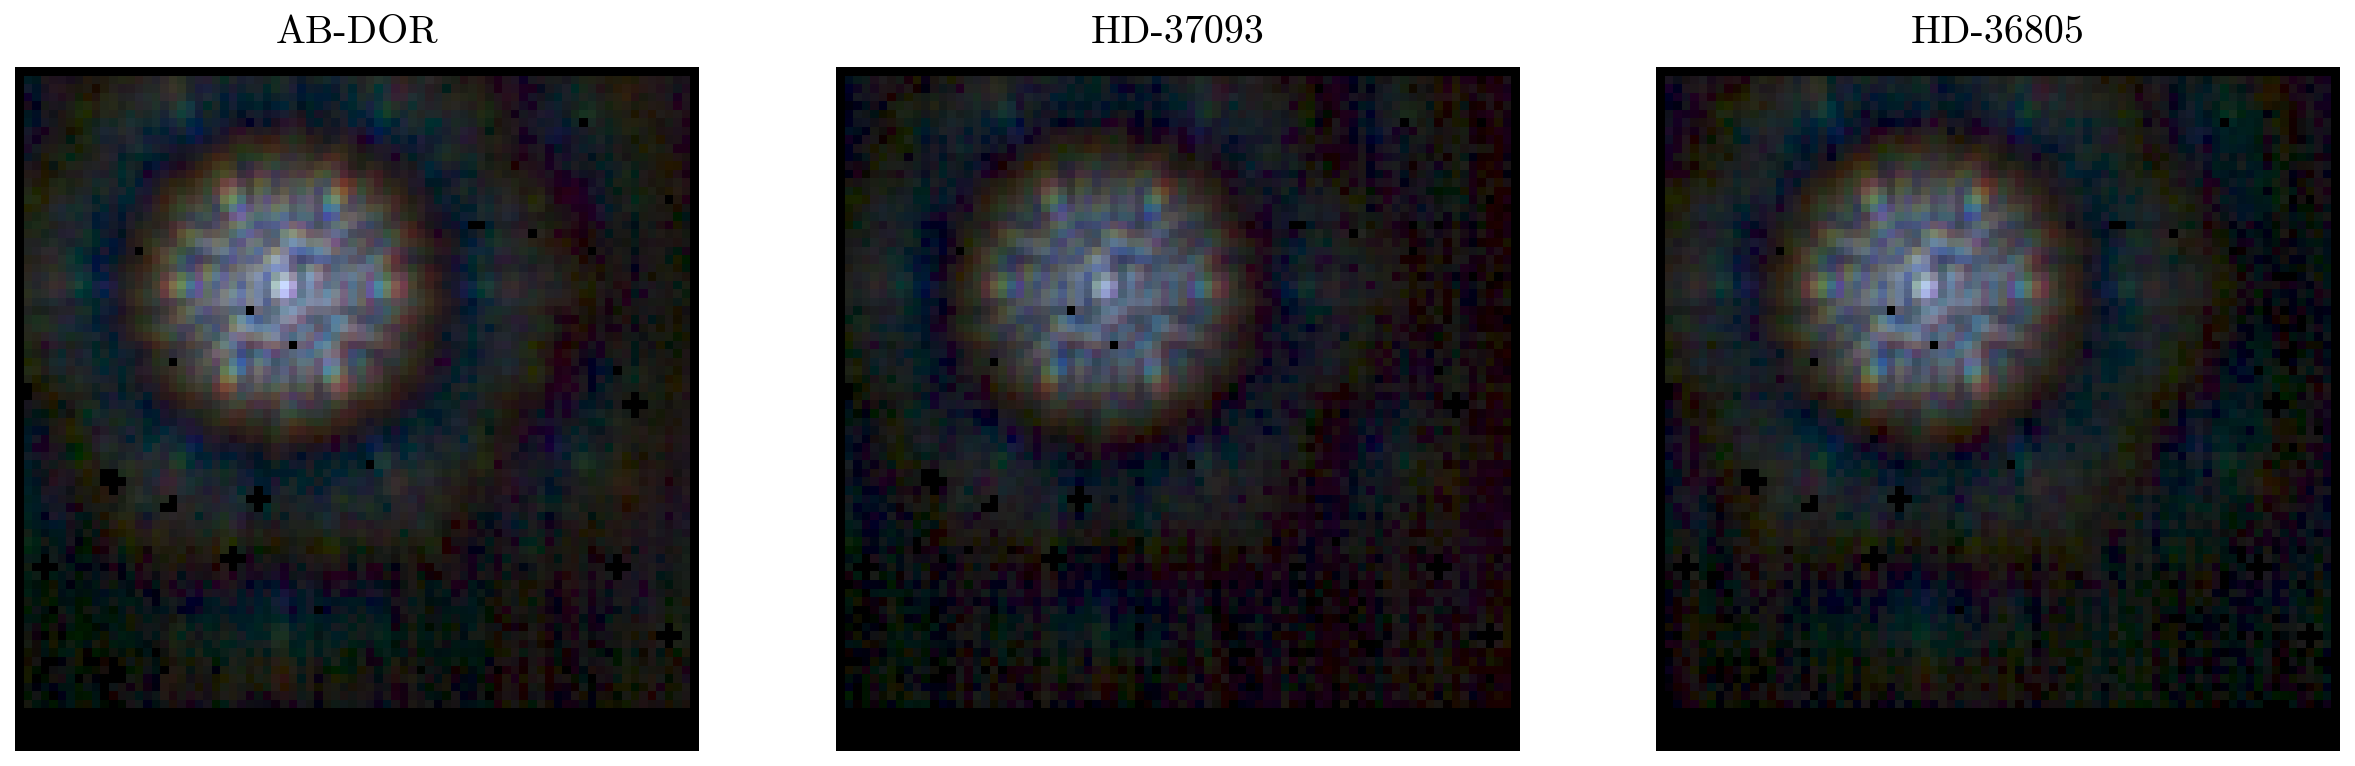

In [5]:
abdor = get_rgb("AB-DOR")
abdorcal1 = get_rgb("HD-37093")
abdorcal2 = get_rgb("HD-36805")


# for filt, ch in abdor.items():
#     # print(ch[0].header)


abdor_rgb = normalise_rgb(abdor, p=0.3)
abdorcal1_rgb = normalise_rgb(abdorcal1, p=0.3)
abdorcal2_rgb = normalise_rgb(abdorcal2, p=0.3)


fig, ax = plt.subplots(1, 3, figsize=(10, 3), dpi=300)

ax[0].imshow(abdor_rgb, origin="lower", interpolation="nearest")
ax[0].set(title="AB-DOR")
ax[0].axis("off")

ax[1].imshow(abdorcal1_rgb, origin="lower", interpolation="nearest")
ax[1].set(title="HD-37093")
ax[1].axis("off")

ax[2].imshow(abdorcal2_rgb, origin="lower", interpolation="nearest")
ax[2].set(title="HD-36805")
ax[2].axis("off")

plt.show()

In [15]:
import planetmapper

data_dir = data_path + "AB-DOR/calslope/"
body = planetmapper.Observation(data_dir + os.listdir(data_dir)[0])

NotFoundError: Spice returns not found for function: bods2c

Check your SPICE kernels are set up correctly - see the help page for more info:
https://planetmapper.readthedocs.io/en/latest/common_issues.html#spice-errors

Kernel directory path: ~/spice_kernels/
Kernel path source: default

In [ ]:
abdor = 

['jw01093020001_03102_00024_nis_calslope.fits',
 'jw01093015001_03103_00001_nis_calslope.fits',
 'jw01093013001_03104_00001_nis_calslope.fits',
 'jw01093020001_03102_00006_nis_calslope.fits',
 'jw01093020001_03102_00016_nis_calslope.fits',
 'jw01093020001_03102_00013_nis_calslope.fits',
 'jw01093020001_03102_00003_nis_calslope.fits',
 'jw01093014001_03102_00001_nis_calslope.fits',
 'jw01093014001_03102_00004_nis_calslope.fits',
 'jw01093018001_03104_00001_nis_calslope.fits',
 'jw01093012001_03102_00001_nis_calslope.fits',
 'jw01093020001_03102_00014_nis_calslope.fits',
 'jw01093020001_03102_00004_nis_calslope.fits',
 'jw01093020001_03102_00001_nis_calslope.fits',
 'jw01093020001_03102_00011_nis_calslope.fits',
 'jw01093020001_03102_00009_nis_calslope.fits',
 'jw01093013001_03103_00001_nis_calslope.fits',
 'jw01093020001_03102_00008_nis_calslope.fits',
 'jw01093020001_03102_00019_nis_calslope.fits',
 'jw01093012001_03103_00001_nis_calslope.fits',
 'jw01093020001_03102_00025_nis_calslope